# 고독사·독거노인 뉴스, 언론은 어떻게 말하는가

### — 텍스트마이닝으로 본 보도 프레임과 감성 (2025.06~2026.06)

> **구글 코랩에서 그대로 실행되는 자기완결형 노트북.**
> `src` import 없이 모든 함수를 셀에 직접 정의한다. 위에서 아래로 실행하면 전체 분석이 재현된다.

| 항목 | 내용 |
|---|---|
| **분석 대상** | 빅카인즈 뉴스 (2025-06-01 ~ 2026-06-01) |
| **수집 키워드(OR)** | 독거노인 · 고독사 · 1인 고령가구 · 노인 고립 · 무연고 사망 |
| **분석 문서 수** | 20,079건 (중복·예외 제거 후) |
| **방법** | 빈도·워드클라우드 → LDA 토픽모델(k=6) → 동시출현 네트워크 → 감성분석(KNU 사전) → 토픽×감성 교차 |

---

## 서론 — 왜 '보도된 고독사'를 분석하는가

**고독사와 독거노인은 한국 사회의 대표적 위험 신호다.** 1인 고령가구는 빠르게 늘고, 아무도 모르게 생을 마감하는 무연고 죽음은 더 이상 예외적 사건이 아니다. 그러나 이 문제에 대한 사회적 인식은 통계가 아니라 대부분 **언론 보도를 통해** 형성된다. 어떤 사건을 얼마나, 어떤 어조로, 어떤 단어와 함께 보도하느냐 — 즉 **미디어 프레임(media frame)** 이 대중의 문제 인식과 정책 의제 설정을 좌우한다.

그렇다면 우리 언론은 고독사·독거노인을 **어떤 프레임으로 말하고 있는가?** 위험을 위험으로 다루는가, 아니면 다른 방식으로 소비하는가? 이 질문에 답하기 위해 1년치 관련 보도 2만여 건을 텍스트마이닝으로 해부한다.

**연구 질문(RQ)**

1. **무엇을 말하는가** — 고독사·독거노인 보도는 어떤 주제(토픽)들로 구성되며, 어느 프레임이 우세한가?
2. **어떤 어조로 말하는가** — 보도 전반의 감성은 긍정적인가 부정적인가?
3. **주제에 따라 어조가 달라지는가** — 어떤 주제를 다룰 때 부정적이고, 어떤 주제는 긍정적인가? (토픽 × 감성)

**분석 설계** — 빈도분석으로 담론의 핵심 어휘를 잡고, LDA로 주제 구조를 분해하며, 동시출현 네트워크로 어휘 간 관계의 중심을 찾고, 감성분석으로 어조를 측정한 뒤, **토픽과 감성을 교차**시켜 "어떤 주제를 말할 때 어조가 달라지는가"를 본다. 네 분석이 하나의 결론으로 수렴하는지를 핵심 기준으로 삼는다.

## 핵심 결과 요약

**고독사·독거노인은 사회적 '위험' 이슈지만, 언론 보도는 주로 복지·나눔이라는 '시혜적·긍정적' 프레임으로 소비된다.** 이 모순이 네 분석 전반에서 일관되게 나타난다.

- **주제 구조** — 담론은 6개 주제로 갈리며, **시혜·복지 프레임(약 50%)이 위기 프레임(약 38%)보다 우세**하다. (나머지 약 12%는 노인의료·돌봄)
- **전체 감성** — 긍정 약 61% / 부정 약 23% / 중립 약 16%로 **뚜렷한 긍정 편향** (평균 점수 +1.47).
- **토픽×감성** — 죽음·재난·질환 등 *고통을 직접 다루는 주제*(재난안전대응·고독사예방·노인의료돌봄)에서만 부정 비율이 상대적으로 높다(약 27~30%). 단, **이들조차 평균 감성은 순(純)긍정**(+0.93~1.07)으로, 보도 전반의 긍정 편향에서 벗어나지 못한다.
- **네트워크** — 핵심어 네트워크의 중심은 `복지·가구·취약·계층·독거노인`으로, 모든 담론이 **'복지 대상으로서의 독거노인'**에 수렴한다.

## 0. 실행 환경 준비 (Colab / 로컬 공용)

> **📌 Colab에서 실행하는 법 (교수자용)**
> 1. 내 구글 드라이브(MyDrive)에 **`BDA/data/raw/`** 폴더를 만들고, 빅카인즈에서 받은 뉴스 엑셀(`*.xlsx`)을 모두 업로드한다.
>    (최종 경로 예: `MyDrive/BDA/data/raw/NewsResult_20250601-20251130.xlsx`)
> 2. 상단 메뉴 **런타임 → 모두 실행**. ③ 셀에서 드라이브 마운트 권한을 묻으면 허용한다.
> 3. 감성사전·한글폰트는 코드가 자동으로 내려받으므로 별도 준비가 필요 없다.

아래 4개 셀을 순서대로 실행한다: ① 패키지 설치 ② 한글 폰트 ③ 경로 설정 ④ 감성사전.
②~④는 Colab/로컬을 자동 감지한다 — 로컬에서는 시스템 한글 폰트(Windows=맑은고딕)와 프로젝트의 `data/` 경로를 그대로 쓴다.

In [1]:
# ① 패키지 설치 (Colab)
!pip install -q konlpy wordcloud pyLDAvis gensim networkx openpyxl
# konlpy(Okt)는 JVM이 필요하다. Colab에는 Java가 기본 설치되어 있다.


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\compo\anaconda3\python.exe -m pip install --upgrade pip


In [2]:
# ② 한글 폰트 등록 (Colab=나눔고딕 설치 / 로컬=시스템 폰트 자동 탐색)
import os, sys, glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

IN_COLAB = "google.colab" in sys.modules

def _setup_korean_font():
    candidates = []
    if IN_COLAB:
        os.system("apt-get -qq install -y fonts-nanum > /dev/null")
        fm._load_fontmanager(try_read_cache=False)  # 새로 설치한 폰트를 즉시 인식
    candidates += glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf")   # Colab/Linux
    candidates += [r"C:\Windows\Fonts\malgun.ttf"]                                  # Windows 맑은고딕
    candidates += ["/System/Library/Fonts/AppleSDGothicNeo.ttc"]                    # macOS
    candidates += glob.glob("/usr/share/fonts/**/Nanum*.ttf", recursive=True)       # 기타 Linux
    for path in candidates:
        if os.path.exists(path):
            try:
                fm.fontManager.addfont(path)
                name = fm.FontProperties(fname=path).get_name()
            except Exception:
                continue
            plt.rcParams["font.family"] = name
            plt.rcParams["axes.unicode_minus"] = False
            return name, path
    return None, None

# FONT_NAME: matplotlib/networkx 라벨용 폰트 '이름' / FONT_PATH: WordCloud용 폰트 '파일경로'
FONT_NAME, FONT_PATH = _setup_korean_font()
print("폰트 등록:", FONT_NAME, "|", FONT_PATH or "한글 폰트를 못 찾음 → 글자가 깨질 수 있음")


폰트 등록: Malgun Gothic | C:\Windows\Fonts\malgun.ttf


In [3]:
# ③ 프로젝트 경로 설정 (Colab=드라이브 마운트 / 로컬=프로젝트 루트 자동 탐색)
import glob, os
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/BDA"   # ← 내 드라이브에 BDA 폴더를 두고 그 안에 data/raw/*.xlsx 업로드
else:
    # 노트북 위치(notebooks/) 기준으로 상위에 data/raw 가 있으면 그곳을 루트로
    PROJECT_DIR = ".." if os.path.isdir("../data/raw") else "."
RAW_DIR = f"{PROJECT_DIR}/data/raw"
excels = glob.glob(f"{RAW_DIR}/*.xlsx")
print("PROJECT_DIR:", os.path.abspath(PROJECT_DIR))
print("발견된 엑셀:", excels)

# 데이터가 없으면 친절히 안내하고 멈춘다 (이후 셀에서 모호한 에러가 나는 것을 방지)
assert excels, (
    f"\n❌ '{RAW_DIR}' 에서 엑셀(.xlsx)을 찾지 못했습니다.\n"
    "   Colab이라면 내 드라이브에 'BDA/data/raw/' 폴더를 만들고 빅카인즈 엑셀을 업로드하세요\n"
    "   (최종 경로 예: MyDrive/BDA/data/raw/NewsResult_...xlsx).")


PROJECT_DIR: D:\project\BDA
발견된 엑셀: ['../data/raw\\NewsResult_20250601-20251130.xlsx', '../data/raw\\NewsResult_20251201-20260601.xlsx']


In [4]:
# ④ KNU 한국어 감성사전 (Colab=다운로드 / 로컬=data/lexicon)
import os
if IN_COLAB:
    os.system("wget -q -O /content/SentiWord_info.json "
              "https://raw.githubusercontent.com/park1200656/KnuSentiLex/master/data/SentiWord_info.json")
    LEXICON_PATH = "/content/SentiWord_info.json"
else:
    LEXICON_PATH = f"{PROJECT_DIR}/data/lexicon/SentiWord_info.json"
print("감성사전:", LEXICON_PATH, "| 크기(bytes):", os.path.getsize(LEXICON_PATH))


감성사전: ../data/lexicon/SentiWord_info.json | 크기(bytes): 1183690


## 0-1. 설정 — 키워드 & 불용어

In [5]:
# 수집 키워드 (참고용)
KEYWORDS = ["독거노인", "고독사", "1인 고령가구", "노인 고립", "무연고 사망"]

# 변별력 없는 행정·보도자료 상투어 (분석에서 제거). 핵심어(복지/가구/취약 등)는 남긴다.
STOP_WORDS = set([
    "기자", "뉴스", "사진", "제공", "무단", "전재", "재배포", "금지", "연합뉴스",
    "오전", "오후", "이날", "지난", "올해", "최근", "관련", "통해", "위해", "대한",
    "이번", "당시", "이상", "이후", "이전", "정도", "가운데", "경우", "때문",
    "지역", "사회", "사업", "지원", "추진", "협의", "전달", "나눔", "서비스",
    "운영", "마련", "실시", "진행", "활동", "대상", "계획", "참여", "행사",
])

## 0-2. 함수 정의 (전처리 / 토픽 / 네트워크 / 감성)

`src/*.py`의 로직을 코랩에서 자기완결로 돌리기 위해 셀에 직접 풀어쓴다.

In [6]:
import re, json
from collections import Counter
from itertools import combinations
import numpy as np
import pandas as pd
from konlpy.tag import Okt

okt = Okt()

# ---- 전처리 ----
_URL = re.compile(r"https?://\S+|www\.\S+")
_EMAIL = re.compile(r"\S+@\S+")
_NONKO = re.compile(r"[^가-힣\s]")
_SP = re.compile(r"\s+")

def clean_text(t):
    if not isinstance(t, str): return ""
    t = _URL.sub(" ", t); t = _EMAIL.sub(" ", t)
    t = _NONKO.sub(" ", t); t = _SP.sub(" ", t)
    return t.strip()

# 복합어(독거노인 등) 보존: Okt가 쪼갠 조각을 다시 합친다
_COMP = [w for w in KEYWORDS]
_COMP_PARTS = sorted([(w, tuple(okt.nouns(w))) for w in _COMP],
                     key=lambda x: -len(x[1]))

def _merge_compounds(nouns):
    res, i, n = [], 0, len(nouns)
    while i < n:
        hit = False
        for w, parts in _COMP_PARTS:
            k = len(parts)
            if k >= 2 and tuple(nouns[i:i+k]) == parts:
                res.append(w); i += k; hit = True; break
        if not hit:
            res.append(nouns[i]); i += 1
    return res

def extract_nouns(text, min_len=2):
    c = clean_text(text)
    if not c: return []
    nouns = _merge_compounds(okt.nouns(c))
    return [w for w in nouns if len(w) >= min_len and w not in STOP_WORDS]

# ---- 감성 토큰 (형용사/동사 어간까지) ----
_SENTI_POS = {"Noun", "Adjective", "Verb", "Adverb"}
def senti_tokens(text, min_len=2):
    c = clean_text(text)
    if not c: return []
    return [w for w, tag in okt.pos(c, norm=True, stem=True)
            if tag in _SENTI_POS and len(w) >= min_len]


In [7]:
# ---- 감성사전 ----
def load_lexicon(path):
    data = json.load(open(path, encoding="utf-8"))
    lex = {}
    for x in data:
        w = x["word"]
        if " " in w or not re.fullmatch(r"[가-힣]+", w): continue
        lex[w] = int(x["polarity"])
    return lex

def score_document(text, lexicon):
    score = pos = neg = n = 0
    for w in senti_tokens(text):
        p = lexicon.get(w)
        if p is None: continue
        score += p; n += 1
        if p > 0: pos += 1
        elif p < 0: neg += 1
    label = "positive" if score > 0 else "negative" if score < 0 else "neutral"
    return score, pos, neg, n, label

# ---- 네트워크 ----
def top_vocab(token_lists, top_n):
    cnt = Counter(w for t in token_lists for w in t)
    return [w for w, _ in cnt.most_common(top_n)]

def build_network(token_lists, top_n=50, min_cooc=300):
    import networkx as nx
    vocab = top_vocab(token_lists, top_n); vset = set(vocab)
    freq = Counter(w for t in token_lists for w in t)
    pairs = Counter()
    for toks in token_lists:
        present = sorted(vset.intersection(toks))
        for a, b in combinations(present, 2): pairs[(a, b)] += 1
    G = nx.Graph()
    for w in vocab: G.add_node(w, freq=int(freq[w]))
    for (a, b), c in pairs.items():
        if c >= min_cooc: G.add_edge(a, b, weight=int(c))
    G.remove_nodes_from([n for n in list(G.nodes) if G.degree(n) == 0])
    return G

def centrality(G):
    import networkx as nx
    deg = nx.degree_centrality(G); bet = nx.betweenness_centrality(G, weight="weight")
    rows = [{"node": n, "degree": round(deg[n], 4),
             "betweenness": round(bet[n], 4), "freq": G.nodes[n]["freq"]} for n in G.nodes]
    return pd.DataFrame(rows).sort_values("degree", ascending=False).reset_index(drop=True)


## 1. 데이터 로드 & 정제

`data/raw/`의 엑셀을 모두 읽어 병합한다. **`뉴스 식별자`는 26자리 문자열이므로 반드시 `dtype=str`로 읽는다**
(숫자로 읽으면 부동소수점 정밀도 손실로 중복제거가 깨진다).

In [8]:
ID, DATE, TITLE, BODY, EXC = "뉴스 식별자", "일자", "제목", "본문", "분석제외 여부"
EXCLUDE_FLAGS = {"예외", "중복", "중복, 예외"}

files = sorted(glob.glob(f"{RAW_DIR}/*.xlsx"))
df = pd.concat([pd.read_excel(f, dtype={ID: str}) for f in files], ignore_index=True)
df = df.drop_duplicates(subset=ID).reset_index(drop=True)
print("병합(식별자 중복제거):", df.shape)

if EXC in df.columns:
    df = df[~df[EXC].isin(EXCLUDE_FLAGS)]
df = df.drop_duplicates(subset=[TITLE, BODY])
df["날짜"] = pd.to_datetime(df[DATE].astype(str), format="%Y%m%d", errors="coerce")
df = df.reset_index(drop=True)
print("정제 후:", df.shape, "| 기간:", df["날짜"].min().date(), "~", df["날짜"].max().date())

C:\Users\compo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


C:\Users\compo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


병합(식별자 중복제거): (20521, 19)
정제 후: (20079, 20) | 기간: 2025-06-01 ~ 2026-06-01


## 2. 빈도 분석 & 워드클라우드

본문에서 Okt로 명사를 추출한다(약 1~2분). 결과는 `df["nouns"]`에 저장해 이후 단계에서 재사용한다.

In [9]:
from tqdm.auto import tqdm
tqdm.pandas(desc="Okt 명사추출")
df["nouns"] = df[BODY].fillna("").progress_apply(extract_nouns)

all_nouns = [w for lst in df["nouns"] for w in lst]
cnt = Counter(all_nouns)
print("총 토큰:", len(all_nouns), "| 고유:", len(cnt))
freq_df = pd.DataFrame(cnt.most_common(30), columns=["단어", "빈도"])
freq_df.head(15)

Okt 명사추출:   0%|          | 0/20079 [00:00<?, ?it/s]

총 토큰: 645829 | 고유: 22461


,단어,빈도
0,복지,8404
1,가구,7209
2,취약,6444
3,계층,6276
4,독거노인,5210
5,노인,4471
6,고독사,4137
7,센터,3847
8,예방,3372
9,안전,3344


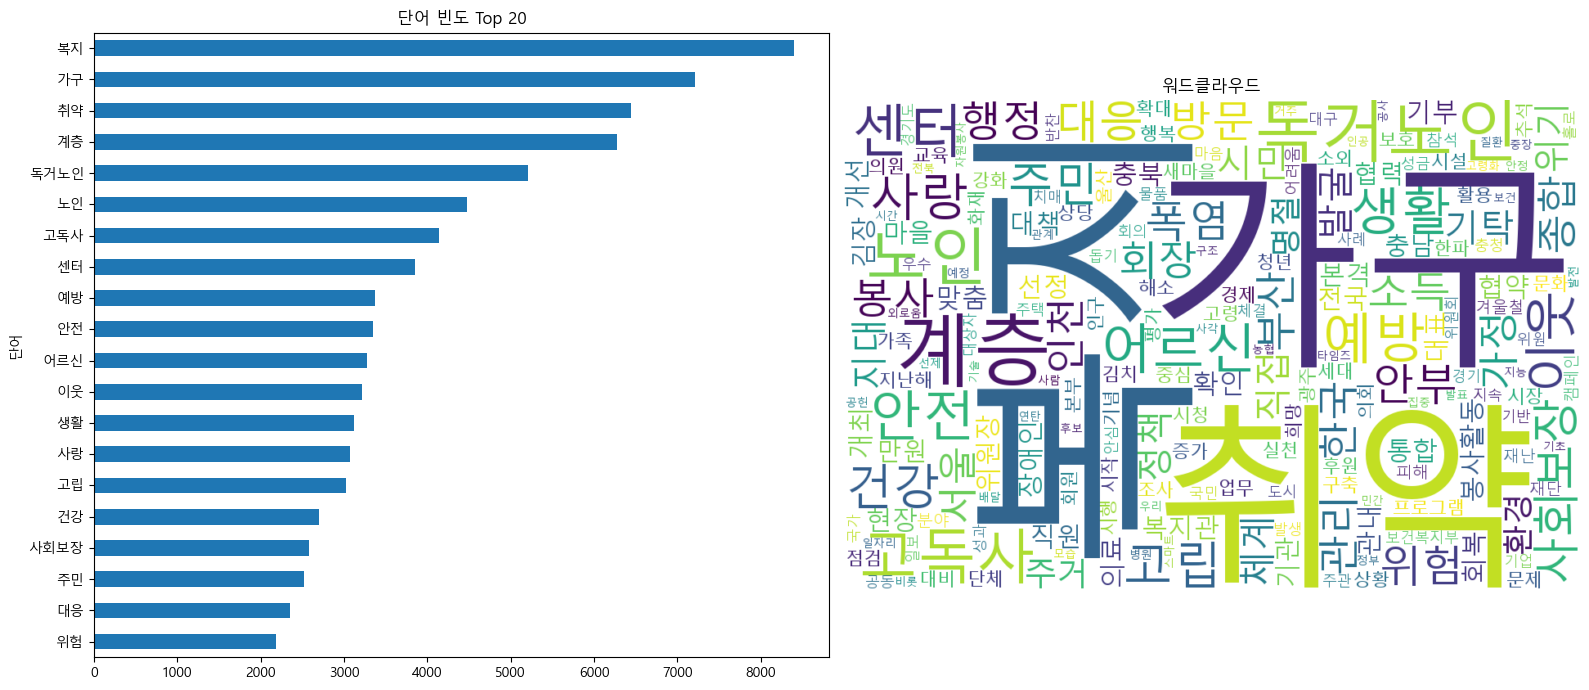

In [10]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
freq_df.set_index("단어")["빈도"][:20][::-1].plot.barh(ax=axes[0])
axes[0].set_title("단어 빈도 Top 20")

wc = WordCloud(font_path=FONT_PATH, width=900, height=600,
               background_color="white", max_words=200
               ).generate_from_frequencies(dict(cnt.most_common(200)))
axes[1].imshow(wc, interpolation="bilinear"); axes[1].axis("off")
axes[1].set_title("워드클라우드")
plt.tight_layout(); plt.show()

**관찰**: 행정 상투어를 제거하면 `복지·가구·취약·계층·독거노인·고독사·센터·예방·안전·어르신·이웃·고립·사회보장·위험`이 부각된다.
'복지/지원'의 시혜 어휘와 '고립/위험/예방'의 위기 어휘가 공존한다.

## 3. LDA 토픽 모델

> **RQ1 — 고독사·독거노인 보도는 어떤 주제로 구성되는가?**

`filter_extremes(no_above=0.5)`로 과빈출어를 걷어내 토픽이 뭉개지는 것을 막는다.
토픽 수는 coherence(c_v)로 탐색하되, **c_v는 실행 환경에 따라 값이 흔들리고 큰 k를 과대평가하는 경향**이 있다.
실제로 **k=6과 k=12가 약 0.51~0.52로 사실상 동률**이라, 어느 쪽이 최고점인지는 환경마다 뒤바뀐다.
이때 큰 k(=12)는 *지명·잡음 토픽*(충북·광주·울산 등)으로 과분할되어 해석이 어려우므로,
해석 가능성과 간결성을 기준으로 **k=6** 으로 고정한다.

In [11]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

token_lists = df["nouns"].tolist()
dictionary = Dictionary(token_lists)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(t) for t in token_lists]
print("사전 크기:", len(dictionary), "| 문서:", len(corpus))

rows = []
for k in range(4, 13, 2):
    m = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k,
                 passes=5, random_state=42)
    cv = CoherenceModel(model=m, texts=token_lists, dictionary=dictionary,
                        coherence="c_v").get_coherence()
    rows.append((k, cv)); print(f"k={k}: coherence={cv:.4f}")
coh = pd.DataFrame(rows, columns=["k", "coherence"])

# c_v 최댓값은 환경에 따라 k=6 또는 k=12로 뒤바뀐다(둘은 약 0.51~0.52로 사실상 동률).
# k=12는 지명·잡음 토픽으로 과분할되어 해석이 어렵다. 해석 가능성을 기준으로 k=6으로 '고정'한다.
BEST_K = 6
print("coherence 최댓값 k =", int(coh.loc[coh["coherence"].idxmax(), "k"]),
      "| 해석성 기준 선택 k =", BEST_K)

사전 크기: 7742 | 문서: 20079


k=4: coherence=0.4724


k=6: coherence=0.5131


k=8: coherence=0.4997


k=10: coherence=0.4935


k=12: coherence=0.5179
coherence 최댓값 k = 12 | 해석성 기준 선택 k = 6


In [12]:
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=BEST_K,
               passes=15, iterations=100, random_state=42)

# 토픽 라벨 (해석) — 결과에 맞게 수정 가능
TOPIC_LABELS = {0: "봉사·나눔", 1: "노인의료·돌봄", 2: "재난안전대응",
                3: "취약계층복지", 4: "지역복지인프라", 5: "고독사예방"}
for tid in range(lda.num_topics):
    words = ", ".join(w for w, _ in lda.show_topic(tid, topn=10))
    print(f"[토픽 {tid}] {TOPIC_LABELS.get(tid, tid)}: {words}")

[토픽 0] 봉사·나눔: 이웃, 사랑, 김장, 회장, 기탁, 독거노인, 계층, 김치, 봉사, 기부
[토픽 1] 노인의료·돌봄: 국가, 통합, 공단, 의료, 국민, 건강, 치매, 노인, 관리, 보훈
[토픽 2] 재난안전대응: 안전, 복지, 대응, 한파, 체계, 노인, 대책, 폭염, 시민, 구축
[토픽 3] 취약계층복지: 취약, 계층, 독거노인, 어르신, 가구, 복지, 사회보장, 생활, 충북, 장애인
[토픽 4] 지역복지인프라: 복지, 문화, 주거, 광주, 센터, 기관, 부문, 단체, 울산, 서울
[토픽 5] 고독사예방: 가구, 고독사, 고립, 예방, 복지, 협약, 안부, 위험, 위기, 발굴


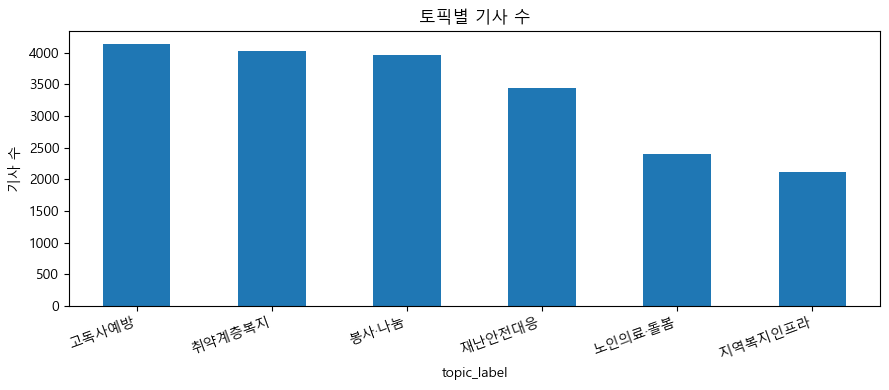

topic_label
고독사예방      20.6
취약계층복지     20.0
봉사·나눔      19.7
재난안전대응     17.1
노인의료·돌봄    12.0
지역복지인프라    10.5
Name: count, dtype: float64

In [13]:
# 문서별 대표 토픽
def dominant(bow):
    d = lda.get_document_topics(bow)
    return max(d, key=lambda x: x[1])[0] if d else -1
df["topic"] = [dominant(b) for b in corpus]
df["topic_label"] = df["topic"].map(TOPIC_LABELS)

dist = df["topic_label"].value_counts()
ax = dist.plot.bar(figsize=(9, 4), title="토픽별 기사 수")
ax.set_ylabel("기사 수"); plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()
(dist / len(df) * 100).round(1)

In [14]:
# pyLDAvis (인터랙티브) — 버전 충돌 시에도 노트북이 멈추지 않도록 방어
try:
    import pyLDAvis, pyLDAvis.gensim_models as gv
    pyLDAvis.enable_notebook()
    vis = gv.prepare(lda, corpus, dictionary)
    display(vis)
except Exception as e:
    print("pyLDAvis 렌더 생략(환경 의존):", type(e).__name__, e)
    print("→ 토픽 내용은 위 셀의 단어 목록과 아래 토픽별 기사 수로 확인 가능합니다.")

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.204112  0.120884       1        1  19.996487
2     -0.129140  0.134010       2        1  18.842000
5     -0.122449  0.087765       3        1  17.508604
0      0.296854 -0.009664       4        1  17.478519
1     -0.234789 -0.006311       5        1  13.477812
4     -0.014589 -0.326683       6        1  12.696579, topic_info=     Term         Freq        Total Category  logprob  loglift
18    고독사  3705.000000  3705.000000  Default  30.0000  30.0000
17     가구  7459.000000  7459.000000  Default  29.0000  29.0000
136    계층  7374.000000  7374.000000  Default  28.0000  28.0000
153    취약  7456.000000  7456.000000  Default  27.0000  27.0000
100  독거노인  5450.000000  5450.000000  Default  26.0000  26.0000
..    ...          ...          ...      ...      ...      ...
123    기념   407.134688   733.566476   Topic6  -5.2567   1.4751
189    대표   473.614019  1276.791164   Topic6  -5.1055   1.0721
15     행정   524.284260  1952.255433   Topic6  -5.0038   0.7491
281    참석   417.600366   873.114178   Topic6  -5.2313   1.3263
809    자살   398.076444   700.570453   Topic6  -5.2792   1.4986

[375 rows x 6 columns], token_table=      Topic      Freq Term
term                      
17        1  0.336221   가구
17        3  0.590129   가구
17        4  0.073599   가구
846       2  0.998343   가동
283       1  0.675202   가정
...     ...       ...  ...
518       6  0.521505   회의
116       1  0.038277   회장
116       4  0.923375   회장
116       6  0.037753   회장
5083      5  0.998367   후보

[629 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 3, 6, 1, 2, 5])

## 4. 단어 동시출현 네트워크

빈도 상위 50개 단어를, 같은 기사에 300회 이상 함께 등장한 쌍으로 연결한다.

노드: 49 | 엣지: 294


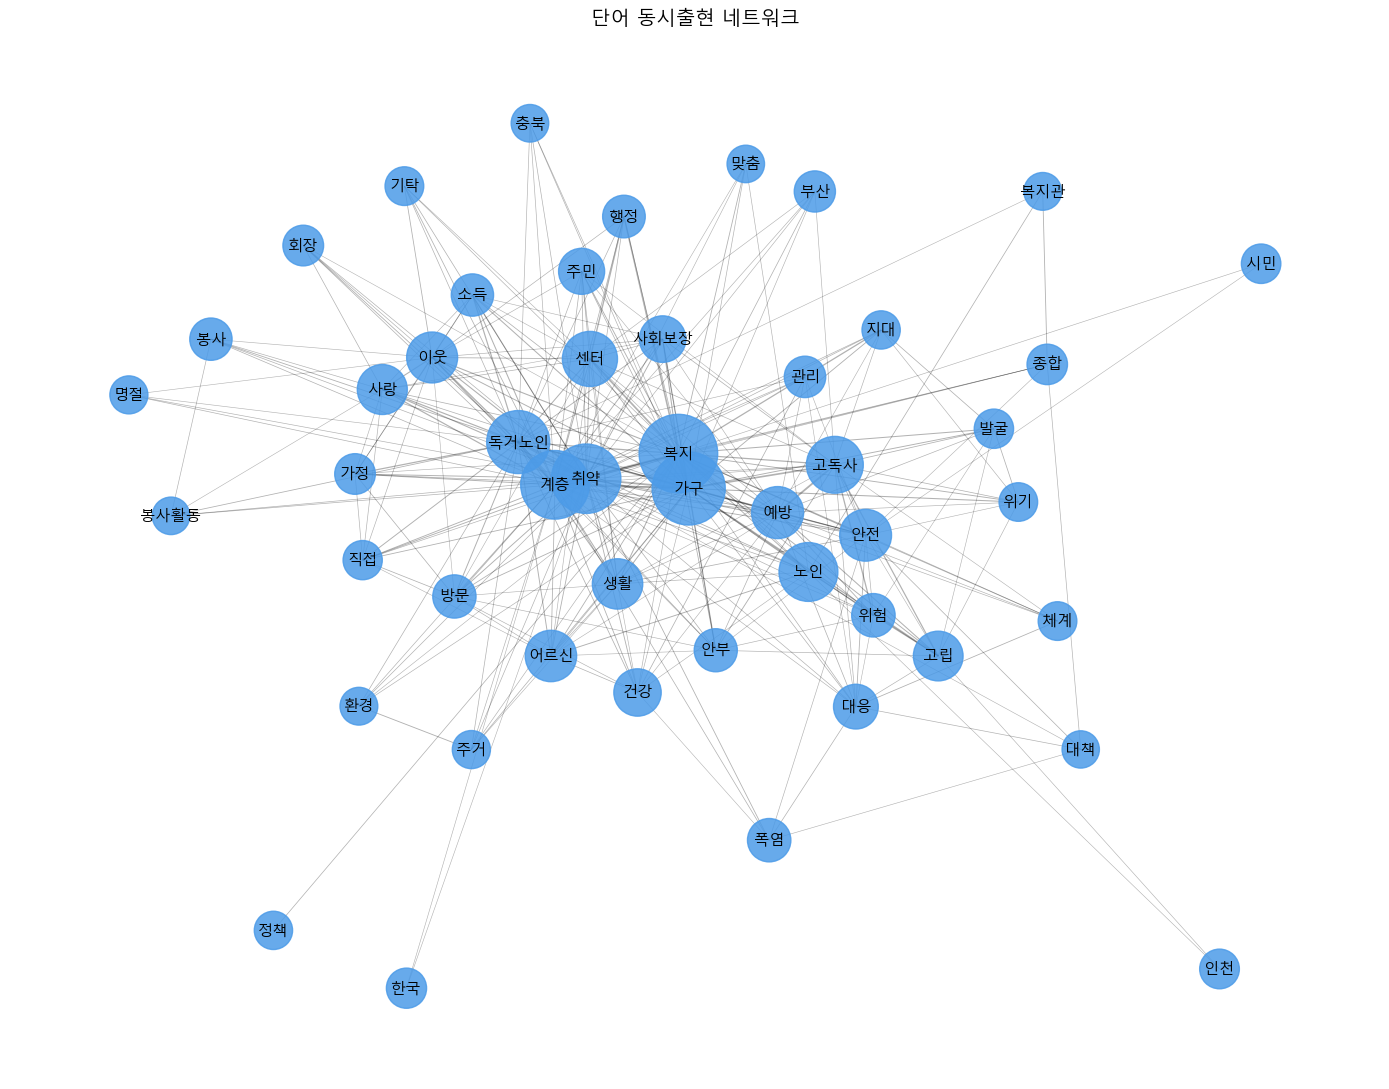

,node,degree,betweenness,freq
0,취약,0.8333,0.0687,6444
1,복지,0.8125,0.1334,8404
2,계층,0.8125,0.1259,6276
3,가구,0.7083,0.0337,7209
4,독거노인,0.6458,0.0665,5210
5,예방,0.4583,0.0629,3372
6,안전,0.3958,0.0598,3344
7,고독사,0.3958,0.0301,4137
8,센터,0.3958,0.0408,3847
9,이웃,0.3750,0.0390,3212


In [15]:
import networkx as nx
G = build_network(token_lists, top_n=50, min_cooc=300)
print("노드:", G.number_of_nodes(), "| 엣지:", G.number_of_edges())

pos = nx.spring_layout(G, k=0.6, seed=42, weight="weight")
freqs = [G.nodes[n]["freq"] for n in G.nodes]; fmax = max(freqs)
sizes = [3000 * (f / fmax) + 200 for f in freqs]
ws = [G[u][v]["weight"] for u, v in G.edges]; wmax = max(ws)
widths = [3 * (w / wmax) + 0.2 for w in ws]

plt.figure(figsize=(14, 11))
nx.draw_networkx_edges(G, pos, width=widths, alpha=0.3)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color="#4C9BE8", alpha=0.85)
nx.draw_networkx_labels(G, pos, font_size=11, font_family=FONT_NAME)
plt.axis("off"); plt.title("단어 동시출현 네트워크", fontsize=14); plt.tight_layout(); plt.show()

centrality(G).head(10)

## 5. 감성 분석

KNU 한국어 감성사전(단어형)으로 기사별 점수를 매긴다. 명사만으로는 감성어를 못 잡으므로
`Okt.pos(stem=True)`로 형용사·동사 어간까지 복원해 매칭한다(약 1~2분).

감성사전 단어 수: 6382


Okt 명사추출:   0%|          | 0/20079 [00:00<?, ?it/s]

senti_label
positive    12281
neutral      3120
negative     4678
평균 점수: 1.473


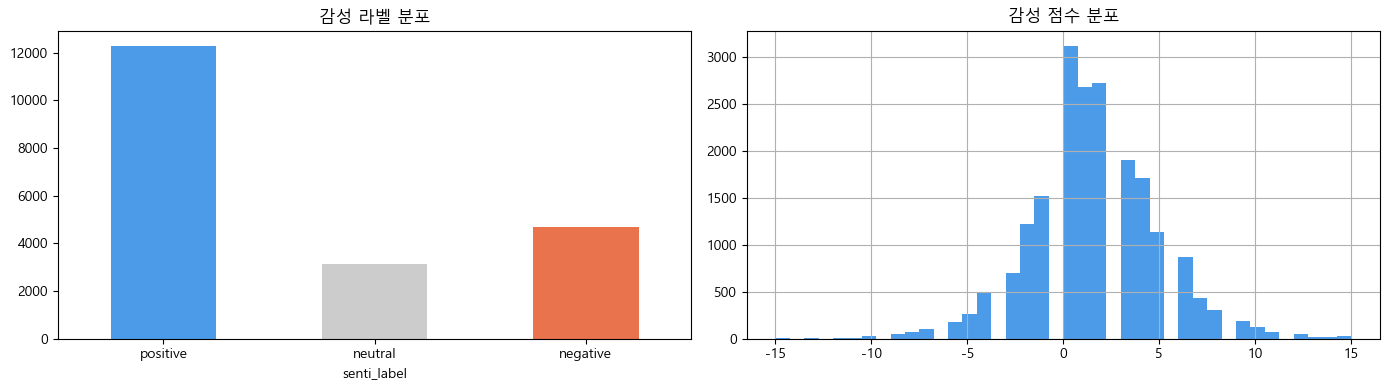

In [16]:
lexicon = load_lexicon(LEXICON_PATH)
print("감성사전 단어 수:", len(lexicon))

res = df[BODY].fillna("").progress_apply(lambda t: score_document(t, lexicon))
df[["senti_score", "senti_pos", "senti_neg", "senti_n", "senti_label"]] = \
    pd.DataFrame(res.tolist(), index=df.index)

dist = df["senti_label"].value_counts().reindex(["positive", "neutral", "negative"])
print(dist.to_string()); print("평균 점수:", round(df["senti_score"].mean(), 3))

colors = ["#4C9BE8", "#CCCCCC", "#E8734C"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dist.plot.bar(ax=axes[0], color=colors); axes[0].set_title("감성 라벨 분포"); axes[0].tick_params(axis="x", rotation=0)
df["senti_score"].clip(-15, 15).hist(bins=40, ax=axes[1], color="#4C9BE8"); axes[1].set_title("감성 점수 분포")
plt.tight_layout(); plt.show()

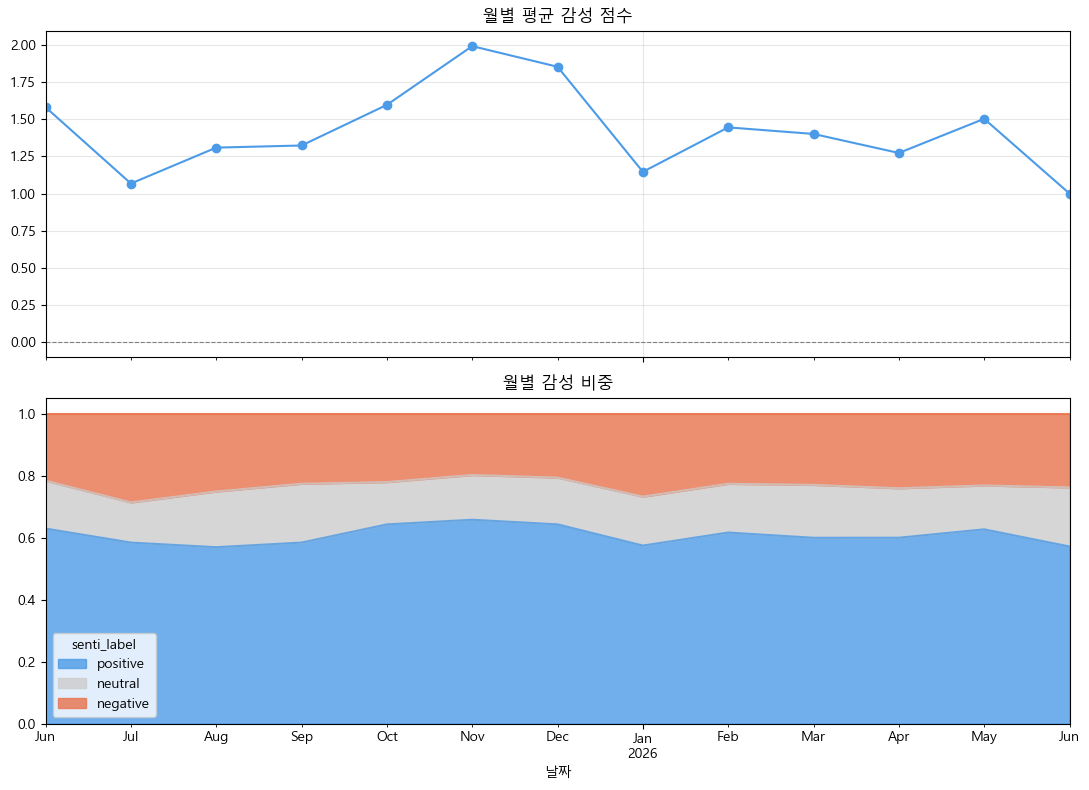

In [17]:
# 월별 감성 추이
g = df.set_index("날짜").groupby([pd.Grouper(freq="ME"), "senti_label"]).size().unstack(fill_value=0)
score_m = df.set_index("날짜").resample("ME")["senti_score"].mean()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
score_m.plot(marker="o", ax=axes[0], color="#4C9BE8"); axes[0].axhline(0, color="gray", ls="--", lw=.8)
axes[0].set_title("월별 평균 감성 점수"); axes[0].grid(alpha=.3)
(g.div(g.sum(axis=1), axis=0))[["positive", "neutral", "negative"]].plot.area(
    ax=axes[1], color=colors, alpha=.8); axes[1].set_title("월별 감성 비중")
plt.tight_layout(); plt.show()

## 6. 토픽 × 감성 교차 — 모순의 근거

> **RQ3 — 어떤 주제를 다룰 때 어조가 달라지는가?**

주제별 감성을 보면 '고통을 직접 다루는 주제'에서만 부정 비율이 올라가는 구조가 드러난다.
표는 평균 감성이 낮은(=상대적으로 덜 긍정적인) 주제부터 정렬했다. **모든 주제의 평균 감성이 0보다 크다**는 점에 주목하라.

In [18]:
cross = df.groupby("topic_label").agg(
    기사수=("senti_label", "size"),
    평균감성=("senti_score", "mean"),
    부정비율=("senti_label", lambda s: round((s == "negative").mean() * 100, 1)),
).sort_values("평균감성")
cross["평균감성"] = cross["평균감성"].round(2)
cross["비중(%)"] = (cross["기사수"] / len(df) * 100).round(1)
cross

,기사수,평균감성,부정비율,비중(%)
topic_label,,,,
재난안전대응,3443,0.93,29.9,17.1
고독사예방,4130,0.93,26.9,20.6
노인의료·돌봄,2401,1.07,28.2,12.0
취약계층복지,4023,1.84,21.6,20.0
봉사·나눔,3964,1.91,18.0,19.7
지역복지인프라,2118,2.36,13.1,10.5


## 7. 결론 — '위험'을 '미담'으로 말하는 언론

서론에서 던진 세 질문에 데이터는 하나의 일관된 답을 준다.
**고독사·독거노인은 명백한 사회적 '위험' 이슈지만, 언론은 이를 주로 복지·나눔이라는 '시혜적·긍정적' 프레임으로 다룬다.**

1. **(RQ1) 프레임의 불균형** — 담론은 6개 주제로 갈리는데, 시혜·복지 프레임(봉사·나눔 + 취약계층복지 + 지역복지인프라 ≈ **50%**)이
   위기 프레임(고독사예방 + 재난안전대응 ≈ **38%**)보다 우세하다. 나머지 약 12%는 노인의료·돌봄이다.
2. **(RQ2) 전반적 긍정 편향** — 죽음·고립을 다루는 주제임에도 전체 감성은 긍정 약 61% / 부정 약 23%, 평균 점수 +1.47.
   '문제 고발'보다 '활동 홍보'가 양적으로 많다.
3. **(RQ3) 부정은 '고통의 영역'에 갇혀 있다** — 토픽×감성 교차에서 부정 비율이 높은(약 27~30%) 주제는
   재난안전대응·고독사예방·**노인의료돌봄**, 즉 죽음·재난·질환을 직접 다루는 주제들뿐이다.
   봉사·나눔·지역인프라 같은 활동 홍보 주제는 강한 긍정이다.
   **그러나 가장 부정적인 주제조차 평균 감성은 순(純)긍정(+0.93)** — 부정 정서는 어디서도 지배적 어조가 되지 못한다.
4. **'복지 대상'으로의 수렴** — 네트워크 중심어가 `복지·가구·취약·계층·독거노인`으로,
   독거노인이 주로 *복지 수혜 대상*으로 호명된다. 토픽·네트워크·감성이 모두 같은 그림을 가리킨다.

### 함의
시혜·미담 중심의 보도는 사회적 관심을 환기하지만, **고독사·고립의 구조적 위험을 '개별 미담'으로 희석**할 수 있다.
위험을 직접 다루는 주제에서조차 어조가 끝내 순긍정으로 기우는 것은, 언론이 위험의 규모·원인·정책 공백보다
*대응 활동의 성과*를 부각하는 경향을 시사한다. 이것이 본 분석의 핵심 시사점이다.

### 분석의 한계
- 감성 점수는 **사전 기반**이라 문맥 부정("외롭지 **않다**")·반어를 반영하지 못한다 → 절대값보다 **주제 간·월별 상대 비교**로 해석.
- 긍정 편향은 실제 보도 성향일 수도, 사전 특성(봉사·지원 어휘가 긍정)일 수도 있어 단정은 피한다.
- 빅카인즈 키워드 OR 검색 기반이라 표본은 해당 키워드 보도에 한정된다.